In [ ]:
import pandas as pd

train_url = "https://raw.githubusercontent.com/touXik/LLM-vs-ML-projet-nlp-/main/data/train_ml.csv"
test_url = "https://raw.githubusercontent.com/touXik/LLM-vs-ML-projet-nlp-/main/data/test_ml.csv"

In [ ]:
!pip install xgboost -q

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)

In [ ]:
train = pd.read_csv(train_url)
test  = pd.read_csv(test_url)

X_train = train.drop("Outcome", axis=1)
y_train = train["Outcome"]

X_test = test.drop("Outcome", axis=1)
y_test = test["Outcome"]

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Classes train : {y_train.value_counts().to_dict()}")

Train : (800, 8)  |  Test : (154, 8)
Classes train : {0: 400, 1: 400}


In [ ]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":           SVC(kernel='rbf', probability=True, random_state=42),
    "XGBoost":       XGBClassifier(n_estimators=100, random_state=42,
                                   eval_metric='logloss', verbosity=0)
}


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("=== VALIDATION CROISÉE 5-FOLD ===\n")

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    cv_results[name] = scores
    print(f"{name}")
    print(f"  F1 par fold : {scores.round(3)}")
    print(f"  Moyenne : {scores.mean():.3f}  (+/- {scores.std():.3f})\n")

=== VALIDATION CROISÉE 5-FOLD ===

Random Forest
  F1 par fold : [0.792 0.824 0.829 0.821 0.847]
  Moyenne : 0.823  (+/- 0.018)

SVM
  F1 par fold : [0.768 0.798 0.807 0.807 0.752]
  Moyenne : 0.786  (+/- 0.022)

XGBoost
  F1 par fold : [0.782 0.812 0.805 0.802 0.826]
  Moyenne : 0.805  (+/- 0.014)



In [ ]:
results = {}

for name, model in models.items():
    # Entraînement sur tout le train
    model.fit(X_train, y_train)

    # Prédictions
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # Métriques
    results[name] = {
        "Accuracy"  : accuracy_score(y_test, y_pred),
        "Precision" : precision_score(y_test, y_pred),
        "Recall"    : recall_score(y_test, y_pred),
        "F1"        : f1_score(y_test, y_pred),
        "AUC"       : roc_auc_score(y_test, y_pred_prob),
        "y_pred"    : y_pred,
        "y_prob"    : y_pred_prob
    }

# Affichage tableau
df_results = pd.DataFrame(results).T[["Accuracy", "Precision", "Recall", "F1", "AUC"]]
print("=== RÉSULTATS SUR LE TEST ===\n")
print(df_results.round(3))

=== RÉSULTATS SUR LE TEST ===

               Accuracy Precision    Recall        F1       AUC
Random Forest  0.733766       0.6  0.722222  0.655462    0.8075
SVM            0.707792  0.558442  0.796296  0.656489  0.786667
XGBoost        0.733766  0.606557  0.685185  0.643478  0.817407


/tmp/ipykernel_311/689461150.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,


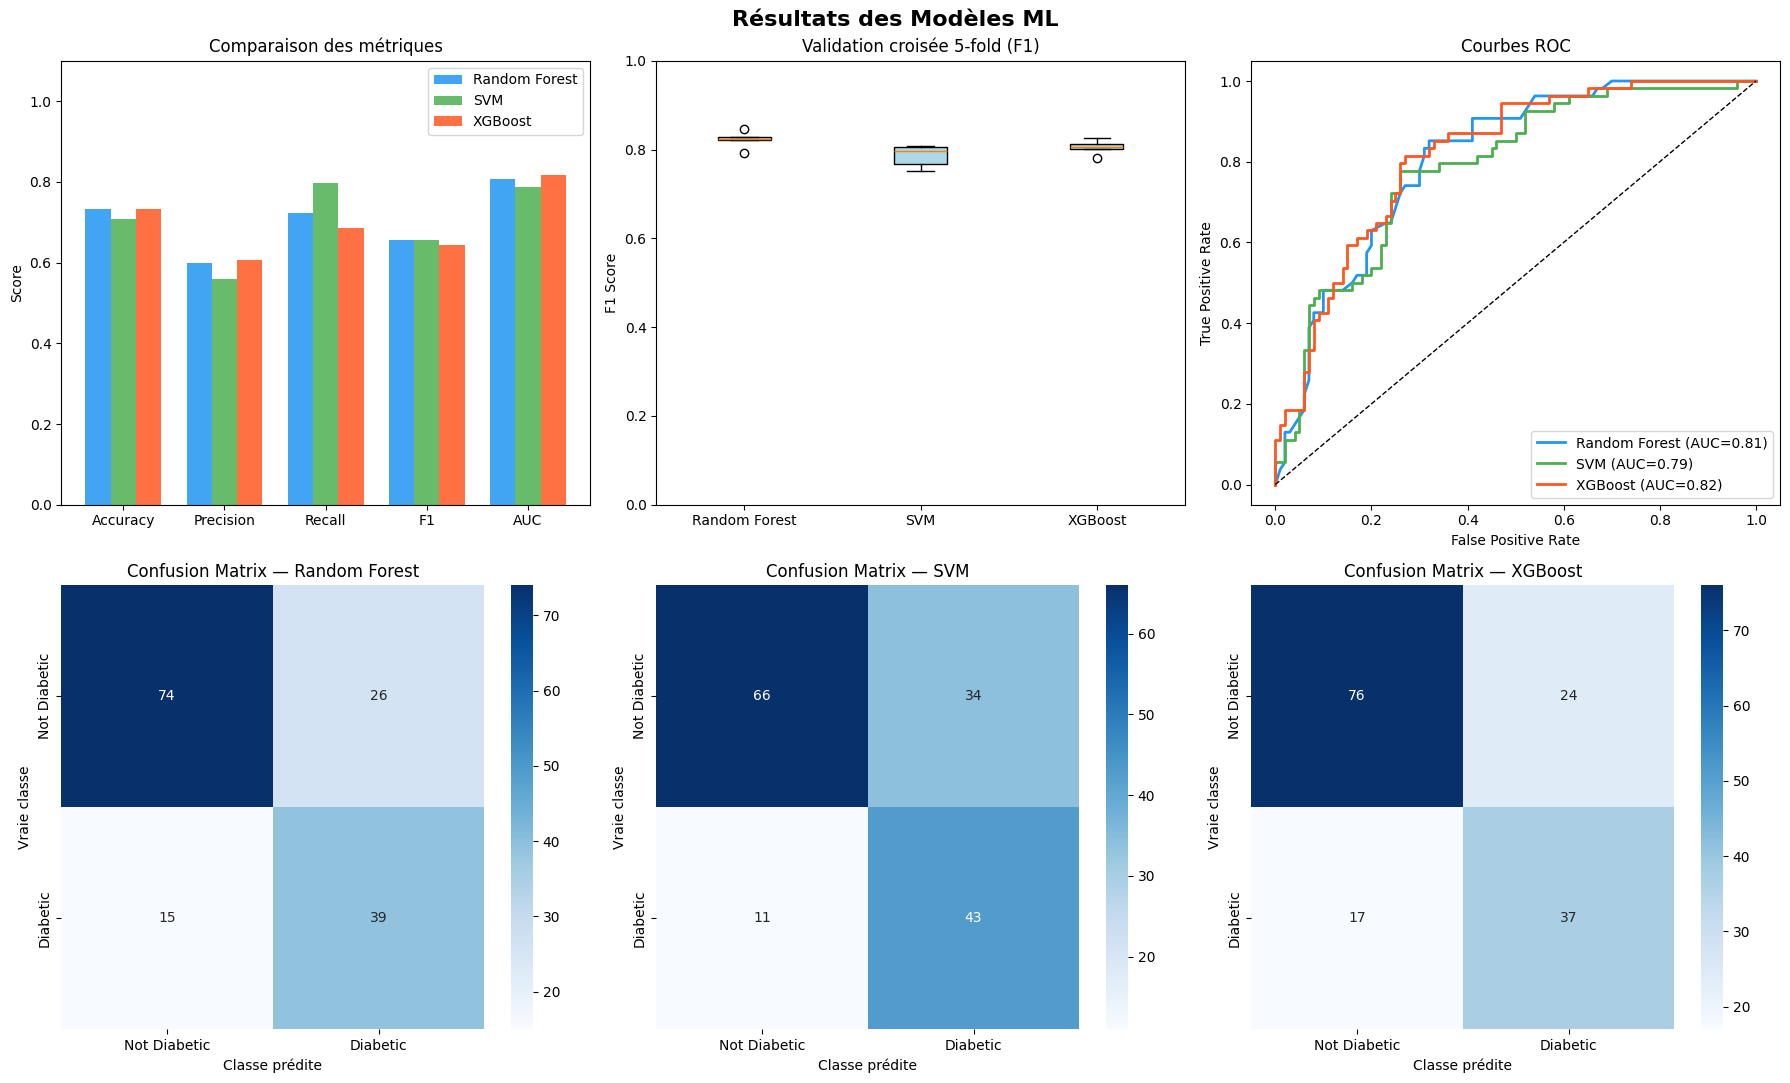

Graphique sauvegardé : resultats_ml.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Résultats des Modèles ML", fontsize=16, fontweight='bold')

# ── Graphique 1 : Comparaison des métriques ──
ax1 = axes[0, 0]
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
x = np.arange(len(metrics))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF5722']

for i, (name, color) in enumerate(zip(results.keys(), colors)):
    vals = [results[name][m] for m in metrics]
    ax1.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)

ax1.set_xticks(x + width)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1.1)
ax1.set_title("Comparaison des métriques")
ax1.legend()
ax1.set_ylabel("Score")

# ── Graphique 2 : Validation croisée (boxplot) ──
ax2 = axes[0, 1]
ax2.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
ax2.set_title("Validation croisée 5-fold (F1)")
ax2.set_ylabel("F1 Score")
ax2.set_ylim(0, 1)

# ── Graphique 3 : Courbes ROC ──
ax3 = axes[0, 2]
for name, color in zip(results.keys(), colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_prob"])
    auc = results[name]["AUC"]
    ax3.plot(fpr, tpr, color=color, label=f"{name} (AUC={auc:.2f})", linewidth=2)
ax3.plot([0,1], [0,1], 'k--', linewidth=1)
ax3.set_title("Courbes ROC")
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.legend()

# ── Graphiques 4, 5, 6 : Matrices de confusion ──
for idx, (name, color) in enumerate(zip(results.keys(), colors)):
    ax = axes[1, idx]
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["Not Diabetic", "Diabetic"],
                yticklabels=["Not Diabetic", "Diabetic"])
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_ylabel("Vraie classe")
    ax.set_xlabel("Classe prédite")

plt.tight_layout()
plt.savefig("resultats_ml.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : resultats_ml.png")

In [ ]:
print("=== RAPPORT DÉTAILLÉ PAR MODÈLE ===\n")

for name in results.keys():
    print(f"{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(
        y_test,
        results[name]["y_pred"],
        target_names=["Not Diabetic", "Diabetic"]
    ))

=== RAPPORT DÉTAILLÉ PAR MODÈLE ===

  Random Forest
              precision    recall  f1-score   support

Not Diabetic       0.83      0.74      0.78       100
    Diabetic       0.60      0.72      0.66        54

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

  SVM
              precision    recall  f1-score   support

Not Diabetic       0.86      0.66      0.75       100
    Diabetic       0.56      0.80      0.66        54

    accuracy                           0.71       154
   macro avg       0.71      0.73      0.70       154
weighted avg       0.75      0.71      0.71       154

  XGBoost
              precision    recall  f1-score   support

Not Diabetic       0.82      0.76      0.79       100
    Diabetic       0.61      0.69      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weigh

# LLM

In [1]:
!pip install mistralai groq google-generativeai pandas scikit-learn matplotlib seaborn -q
print("Installations OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.3/509.3 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.3/160.3 kB 15.1 MB/s eta 0:00:00
Installations OK


In [23]:
from google.colab import userdata

# MISTRAL_API_KEY = userdata.get('MISTRAL_API_KEY')
GROQ_API_KEY    = userdata.get('Groq_api_key')
# GEMINI_API_KEY  = userdata.get('Gemini_API_Key')

print("Clés chargées")

Clés chargées


In [8]:
import pandas as pd

data_zero_url = "https://raw.githubusercontent.com/touXik/LLM-vs-ML-projet-nlp-/main/data/test_zeroshot.csv"


In [9]:


test = pd.read_csv(data_zero_url)

print(f"Nombre de patients : {len(test)}")
print(f"\nExemple de texte :\n{test['text'].iloc[0]}")
print(f"\nVraie réponse : {test['label'].iloc[0]}")

Nombre de patients : 154

Exemple de texte :
The patient is 40 years old. She had 7 pregnancies. Her glucose level is 159.0. Her blood pressure is 64.0. Her skin thickness is 0.0. Her insulin level is 0.0. Her BMI is 27.4. Her diabetes pedigree function is 0.294. Is this patient diabetic or not diabetic?

Vraie réponse : 0


In [25]:
import time
# from mistralai import Mistral
# import groq
import google.generativeai as genai

# # ── Mistral ──
# def call_mistral(text, model="open-mistral-7b"):
#     client = Mistral(api_key=MISTRAL_API_KEY)
#     prompt = f"{text}\nAnswer with only 'diabetic' or 'not diabetic'."
#     response = client.chat.complete(
#         model=model,
#         messages=[{"role": "user", "content": prompt}],
#         temperature=0.1,
#         max_tokens=10
#     )
#     return response.choices[0].message.content.strip().lower()

# ── Groq (Llama3) ──
def call_groq(text, model="llama-3.1-8b-instant"):
    client = groq.Groq(api_key=GROQ_API_KEY)
    prompt = f"{text}\nAnswer with only 'diabetic' or 'not diabetic'."
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1,
        max_tokens=10
    )
    return response.choices[0].message.content.strip().lower()

# ── Gemini ──
def call_gemini(text, model="gemini-2.0-flash"):
    genai.configure(api_key=GEMINI_API_KEY)
    prompt = f"{text}\nAnswer with only 'diabetic' or 'not diabetic'."
    m = genai.GenerativeModel(model)
    response = m.generate_content(
        prompt,
        generation_config={"temperature": 0.1, "max_output_tokens": 10}
    )
    return response.text.strip().lower()

print("Fonctions définies")

Fonctions définies


In [24]:
import groq

client = groq.Groq(api_key=GROQ_API_KEY)

# 1. Vérifier les modèles disponibles
print("=== MODÈLES GROQ DISPONIBLES ===")
models = client.models.list()
for m in models.data:
    print(m.id)

=== MODÈLES GROQ DISPONIBLES ===
meta-llama/llama-prompt-guard-2-86m
meta-llama/llama-guard-4-12b
groq/compound
meta-llama/llama-4-scout-17b-16e-instruct
openai/gpt-oss-safeguard-20b
allam-2-7b
whisper-large-v3
meta-llama/llama-prompt-guard-2-22m
openai/gpt-oss-20b
llama-3.3-70b-versatile
whisper-large-v3-turbo
groq/compound-mini
llama-3.1-8b-instant
qwen/qwen3-32b
moonshotai/kimi-k2-instruct-0905
moonshotai/kimi-k2-instruct
openai/gpt-oss-120b
meta-llama/llama-4-maverick-17b-128e-instruct
canopylabs/orpheus-v1-english
canopylabs/orpheus-arabic-saudi


In [20]:
# D'abord vérifie quels modèles sont disponibles
import google.generativeai as genai

genai.configure(api_key=GEMINI_API_KEY)

print("=== MODÈLES GEMINI DISPONIBLES ===")
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

=== MODÈLES GEMINI DISPONIBLES ===
models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2025


In [21]:
def parse_response(response):
    """Convertit la réponse texte en 0 ou 1"""
    response = response.lower().strip()
    if "not diabetic" in response:
        return 0
    elif "diabetic" in response:
        return 1
    else:
        return -1  # réponse non reconnue

print("Parser défini")

Parser défini


In [26]:
test_text = test["text"].iloc[0]
print(f"Texte envoyé :\n{test_text}\n")

try:
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": f"{test_text}\nAnswer with only 'diabetic' or 'not diabetic'."}],
        temperature=0.1,
        max_tokens=10
    )
    print(f"Réponse : {response.choices[0].message.content}")
except Exception as e:
    print(f" Erreur : {e}")

Texte envoyé :
The patient is 40 years old. She had 7 pregnancies. Her glucose level is 159.0. Her blood pressure is 64.0. Her skin thickness is 0.0. Her insulin level is 0.0. Her BMI is 27.4. Her diabetes pedigree function is 0.294. Is this patient diabetic or not diabetic?

✅ Réponse : diabetic


In [27]:
from tqdm import tqdm

# Définition des modèles à tester
llm_models = {
    # "Mistral-7B"    : lambda text: call_mistral(text, "open-mistral-7b"),
    # "Mixtral-8x7B"  : lambda text: call_mistral(text, "open-mixtral-8x7b"),
    # "Llama3-8B"     : lambda text: call_groq(text, "llama3-8b-8192"),
    # "Llama3-70B"    : lambda text: call_groq(text, "llama3-70b-8192"),
    # "Gemini-Flash"  : lambda text: call_gemini(text, "gemini-1.5-flash"),

    "Llama3.1-8B"   : lambda text: call_groq(text, "llama-3.1-8b-instant"),
    "Llama3.3-70B"  : lambda text: call_groq(text, "llama-3.3-70b-versatile"),

        # ── Gemini (Google) ──
    # "Gemini-2.0-Flash"      : lambda text: call_gemini(text, "gemini-2.0-flash"),
    # "Gemini-2.5-Flash"      : lambda text: call_gemini(text, "gemini-2.5-flash"),
    # "Gemini-2.5-Pro"        : lambda text: call_gemini(text, "gemini-2.5-pro"),
}

llm_predictions = {}

for model_name, call_fn in llm_models.items():
    print(f"\n Test de {model_name}...")
    preds = []
    errors = 0

    for i, row in tqdm(test.iterrows(), total=len(test)):
        try:
            response = call_fn(row["text"])
            pred = parse_response(response)
            preds.append(pred)
        except Exception as e:
            print(f" Erreur patient {i} : {e}")
            preds.append(-1)
            errors += 1

        time.sleep(0.5)  # éviter de dépasser les limites API

    llm_predictions[model_name] = preds
    valid = sum(1 for p in preds if p != -1)
    print(f"{model_name} terminé | Valides: {valid}/154 | Erreurs: {errors}")


 Test de Llama3.1-8B...


100%|██████████| 154/154 [06:02<00:00,  2.36s/it]


Llama3.1-8B terminé | Valides: 154/154 | Erreurs: 0

 Test de Llama3.3-70B...


100%|██████████| 154/154 [06:08<00:00,  2.39s/it]

Llama3.3-70B terminé | Valides: 154/154 | Erreurs: 0


In [33]:
# Voir les 10 premières prédictions
print("=== ÉCHANTILLON DES PRÉDICTIONS ===\n")
print(f"{'Patient':<10} {'Vraie réponse':<20} {'Llama3.1-8B':<20} {'Llama3.3-70B':<20}")
print("-" * 70)

for i in range(10):
    vrai = "diabetic" if test["label"].iloc[i] == 1 else "not diabetic"
    pred_8b  = "diabetic" if llm_predictions["Llama3.1-8B"][i] == 1 else "not diabetic" if llm_predictions["Llama3.1-8B"][i] == 0 else "❓ inconnu"
    pred_70b = "diabetic" if llm_predictions["Llama3.3-70B"][i] == 1 else "not diabetic" if llm_predictions["Llama3.3-70B"][i] == 0 else "❓ inconnu"

    # Indicateur correct/incorrect
    ok_8b  = "True" if llm_predictions["Llama3.1-8B"][i] == test["label"].iloc[i] else "False"
    ok_70b = "True" if llm_predictions["Llama3.3-70B"][i] == test["label"].iloc[i] else "False"

    print(f"{i:<10} {vrai:<20} {ok_8b} {pred_8b:<18} {ok_70b} {pred_70b:<18}")

=== ÉCHANTILLON DES PRÉDICTIONS ===

Patient    Vraie réponse        Llama3.1-8B          Llama3.3-70B        
----------------------------------------------------------------------
0          not diabetic         False diabetic           False diabetic          
1          not diabetic         True not diabetic       True not diabetic      
2          not diabetic         False diabetic           False diabetic          
3          diabetic             False not diabetic       False not diabetic      
4          not diabetic         True not diabetic       True not diabetic      
5          not diabetic         True not diabetic       True not diabetic      
6          diabetic             False not diabetic       True diabetic          
7          diabetic             True diabetic           False not diabetic      
8          not diabetic         True not diabetic       True not diabetic      
9          not diabetic         False diabetic           False diabetic          


In [28]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

y_true = test["label"].values
llm_results = {}

print("=== RÉSULTATS ZERO-SHOT ===\n")

for model_name, preds in llm_predictions.items():
    # Filtrer les réponses non reconnues
    valid_idx = [i for i, p in enumerate(preds) if p != -1]
    y_true_valid = y_true[valid_idx]
    y_pred_valid = [preds[i] for i in valid_idx]

    if len(y_pred_valid) == 0:
        print(f"{model_name} : aucune prédiction valide\n")
        continue

    llm_results[model_name] = {
        "Accuracy"  : accuracy_score(y_true_valid, y_pred_valid),
        "Precision" : precision_score(y_true_valid, y_pred_valid, zero_division=0),
        "Recall"    : recall_score(y_true_valid, y_pred_valid, zero_division=0),
        "F1"        : f1_score(y_true_valid, y_pred_valid, zero_division=0),
        "y_pred"    : y_pred_valid,
        "y_true"    : y_true_valid,
        "valid"     : len(valid_idx)
    }

    print(f"{model_name} ({len(valid_idx)}/154 valides)")
    print(f"  Accuracy  : {llm_results[model_name]['Accuracy']:.3f}")
    print(f"  Precision : {llm_results[model_name]['Precision']:.3f}")
    print(f"  Recall    : {llm_results[model_name]['Recall']:.3f}")
    print(f"  F1        : {llm_results[model_name]['F1']:.3f}\n")

=== RÉSULTATS ZERO-SHOT ===

Llama3.1-8B (154/154 valides)
  Accuracy  : 0.675
  Precision : 0.529
  Recall    : 0.667
  F1        : 0.590

Llama3.3-70B (154/154 valides)
  Accuracy  : 0.675
  Precision : 0.528
  Recall    : 0.704
  F1        : 0.603



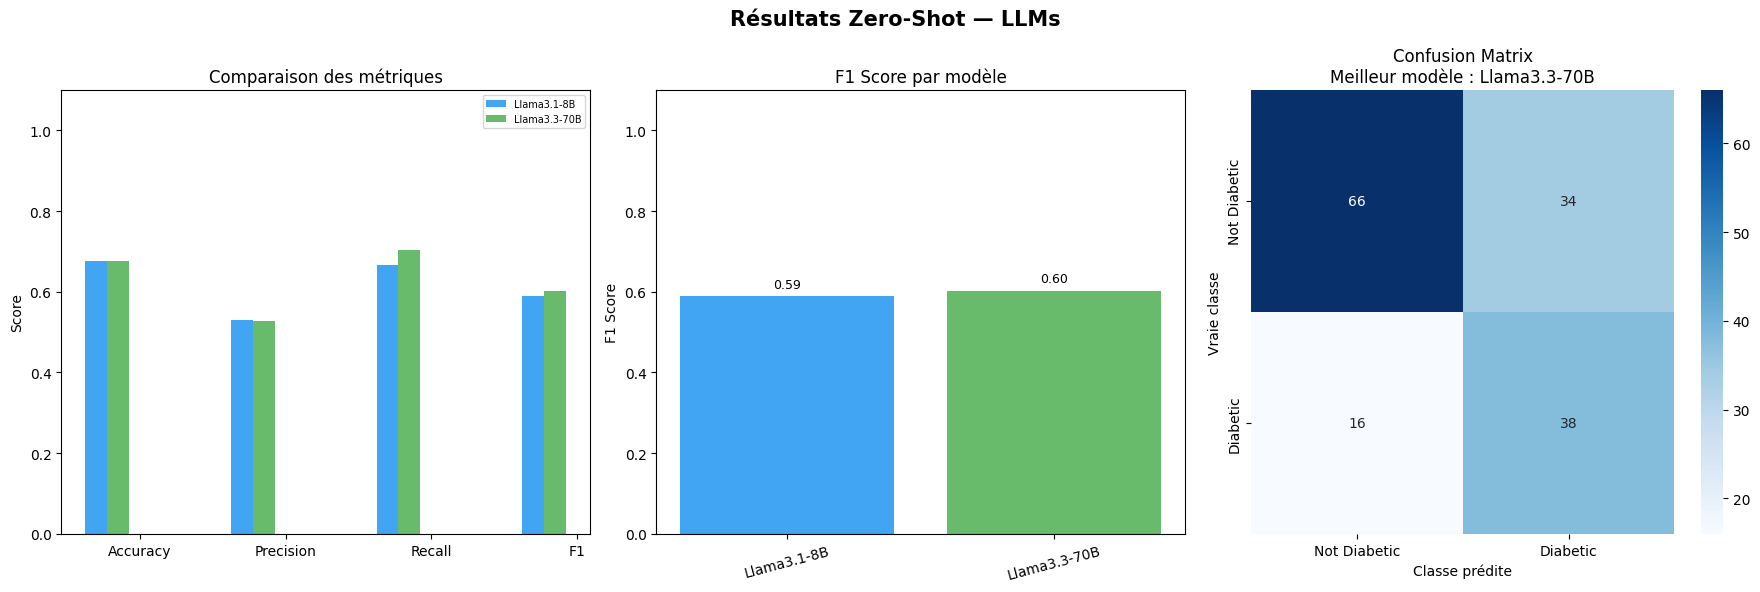


 Meilleur modèle Zero-Shot : Llama3.3-70B


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Résultats Zero-Shot — LLMs", fontsize=15, fontweight='bold')

model_names = list(llm_results.keys())
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']
metrics = ["Accuracy", "Precision", "Recall", "F1"]

# ── Graphique 1 : Comparaison métriques ──
ax1 = axes[0]
x = np.arange(len(metrics))
width = 0.15
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [llm_results[name][m] for m in metrics]
    ax1.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)
ax1.set_xticks(x + width * 2)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1.1)
ax1.set_title("Comparaison des métriques")
ax1.legend(fontsize=7)
ax1.set_ylabel("Score")

# ── Graphique 2 : F1 Score comparaison ──
ax2 = axes[1]
f1_scores = [llm_results[n]["F1"] for n in model_names]
bars = ax2.bar(model_names, f1_scores, color=colors[:len(model_names)], alpha=0.85)
ax2.set_ylim(0, 1.1)
ax2.set_title("F1 Score par modèle")
ax2.set_ylabel("F1 Score")
for bar, val in zip(bars, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.2f}", ha='center', fontsize=9)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15)

# ── Graphique 3 : Matrice confusion meilleur modèle ──
ax3 = axes[2]
best_model = max(llm_results, key=lambda n: llm_results[n]["F1"])
cm = confusion_matrix(llm_results[best_model]["y_true"],
                      llm_results[best_model]["y_pred"])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=["Not Diabetic", "Diabetic"],
            yticklabels=["Not Diabetic", "Diabetic"])
ax3.set_title(f"Confusion Matrix\nMeilleur modèle : {best_model}")
ax3.set_ylabel("Vraie classe")
ax3.set_xlabel("Classe prédite")

plt.tight_layout()
plt.savefig("resultats_zeroshot.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n Meilleur modèle Zero-Shot : {best_model}")

In [31]:
# Sauvegarder les prédictions
df_preds = test.copy()
for model_name, preds in llm_predictions.items():
    df_preds[model_name] = preds

df_preds.to_csv("predictions_zeroshot.csv", index=False)

# Sauvegarder les métriques
df_metrics = pd.DataFrame(llm_results).T[["Accuracy", "Precision", "Recall", "F1"]]
df_metrics.to_csv("metrics_zeroshot.csv")

print(" Résultats sauvegardés !")
print(df_metrics.round(3))

 Résultats sauvegardés !
              Accuracy Precision    Recall        F1
Llama3.1-8B   0.675325  0.529412  0.666667  0.590164
Llama3.3-70B  0.675325  0.527778  0.703704  0.603175
